<a href="https://colab.research.google.com/github/diyabiswas623-dotcom/ITA_Class_Assignment/blob/main/ITA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Consolidated Analysis Output

### 1. Data Loading and Preprocessing

The dataset was successfully loaded, revealing 1470 entries across 35 columns. Initial inspection confirmed no missing values. Three constant columns ('EmployeeCount', 'Over18', 'StandardHours') were dropped, reducing the dataset to 32 columns. Binary categorical features ('Attrition', 'OverTime', 'Gender') were encoded, and multi-class categorical features were one-hot encoded. Finally, numerical features were standardized using `StandardScaler`.

**DataFrame Info after initial load (from cell `8379dc14`):**

In [16]:
print(f"Shape of the DataFrame: {df.shape}")
print("\nInformation about the DataFrame:\n")
df.info()

Shape of the DataFrame: (1470, 47)

Information about the DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int8 
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   EnvironmentSatisfaction            1470 non-null   int64
 7   Gender                             1470 non-null   int8 
 8   HourlyRate                         1470 non-null   int64
 9   JobInvolvement                     1470 non-null   int64
 10  JobLevel                           1470 non-null   int64
 11  JobSatisfact

**DataFrame Shape after dropping single-value columns (from cell `78d29ce3`):**

In [17]:
print(f"New shape of DataFrame after dropping columns: {df.shape}")

New shape of DataFrame after dropping columns: (1470, 47)


**First 5 rows of encoded binary categorical columns (from cell `de9d40f9`):**

In [18]:
print(df[['Attrition', 'OverTime', 'Gender']].head())

   Attrition  OverTime  Gender
0          1         1       0
1          0         1       0
2          0         1       1
3          1         0       0
4          0         0       0


**DataFrame shape and first 5 rows after one-hot encoding (from cell `c783b07d`):**

In [19]:
print(f"DataFrame shape after one-hot encoding: {df.shape}")
print(df.head())

DataFrame shape after one-hot encoding: (1470, 47)
   Age  Attrition  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0   33          1        961                 8          4               1   
1   56          0        195                22          2               2   
2   59          0       1263                29          3               3   
3   26          1       1060                17          3               4   
4   34          0       1328                11          4               5   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  ...  \
0                        4       0          30               2  ...   
1                        1       0          59               1  ...   
2                        2       1          88               2  ...   
3                        1       0          31               1  ...   
4                        3       0          69               2  ...   

   JobRole_Laboratory Technician  JobRole_Manager  \
0     

**Shape of preprocessed features (`X_preprocessed`) after standardization (from cell `a197079c`):**

In [20]:
print(f"Shape of preprocessed features (X_preprocessed): {X_preprocessed.shape}")
print(X_preprocessed.head())

Shape of preprocessed features (X_preprocessed): (1470, 45)
        Age  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0 -0.492401   0.397246         -0.853571   0.741681       -1.730873   
1  1.402008  -1.471970          0.847125  -0.672419       -1.728516   
2  1.649105   1.134196          1.697473   0.034631       -1.726160   
3 -1.068960   0.638829          0.239734   0.034631       -1.723803   
4 -0.410035   1.292811         -0.489136   0.741681       -1.721447   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                 1.326344   -1.717213       -0.466120  0.460980   
1                -1.339643   -0.328128       -1.358302  1.257266   
2                -0.450981    1.060958       -0.466120  0.460980   
3                -1.339643   -1.669314       -1.358302  2.053553   
4                 0.437681    0.150867       -0.466120 -1.131594   

   JobSatisfaction  ...  JobRole_Human Resources  \
0        -1.282293  ...                        0   


### 2. Unsupervised Learning — K-Means Clustering

**Elbow Method for Optimal K (from cell `83d50dfd`):**
The Elbow Method plot indicated that `k=3` is a reasonable choice for the optimal number of clusters.

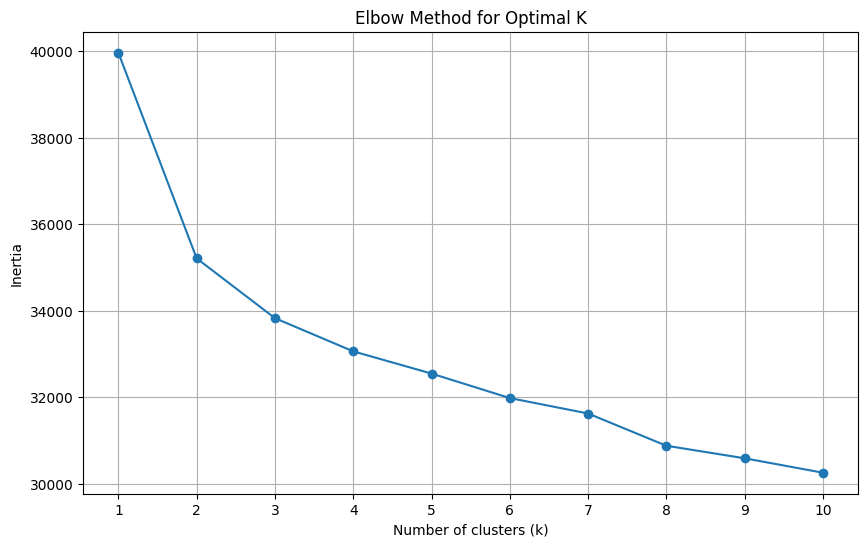

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X_preprocessed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**K-Means Clustering Visualization (from cell `6868ed2e`):**
Clusters were visualized using 'MonthlyIncome' and 'JobSatisfaction'.

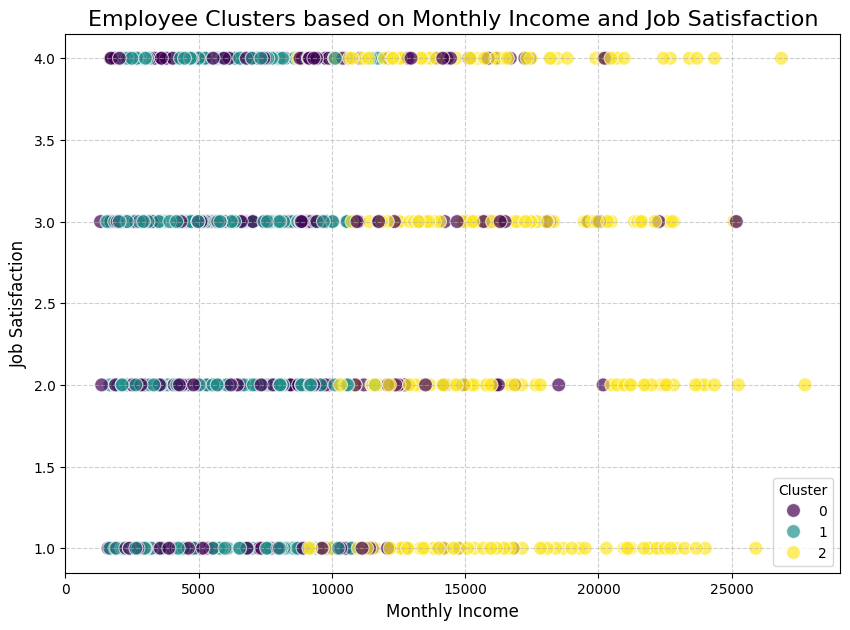

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(X_preprocessed)
df['Cluster'] = kmeans.labels_

plt.figure(figsize=(10, 7))
sns.scatterplot(x='MonthlyIncome', y='JobSatisfaction', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Employee Clusters based on Monthly Income and Job Satisfaction', fontsize=16)
plt.xlabel('Monthly Income', fontsize=12)
plt.ylabel('Job Satisfaction', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3. Supervised Learning — Random Forest Classifier

**SMOTE for Class Imbalance (from cell `a278e0ce`):**
SMOTE was applied to balance the 'Attrition' classes.

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y)

print(f"Shape of X_resampled after SMOTE: {X_resampled.shape}")
print(f"Shape of y_resampled after SMOTE: {y_resampled.shape}")
print("\nClass distribution of y_resampled after SMOTE:")
print(y_resampled.value_counts())

Shape of X_resampled after SMOTE: (2124, 45)
Shape of y_resampled after SMOTE: (2124,)

Class distribution of y_resampled after SMOTE:
Attrition
1    1062
0    1062
Name: count, dtype: int64


**Random Forest Classifier Evaluation (from cell `491d1391`):**
The model was trained with k=5 cross-validation and evaluated on a test set.

Accuracy: 0.8259
Precision: 0.9107
Recall: 0.7217
F1-Score: 0.8053


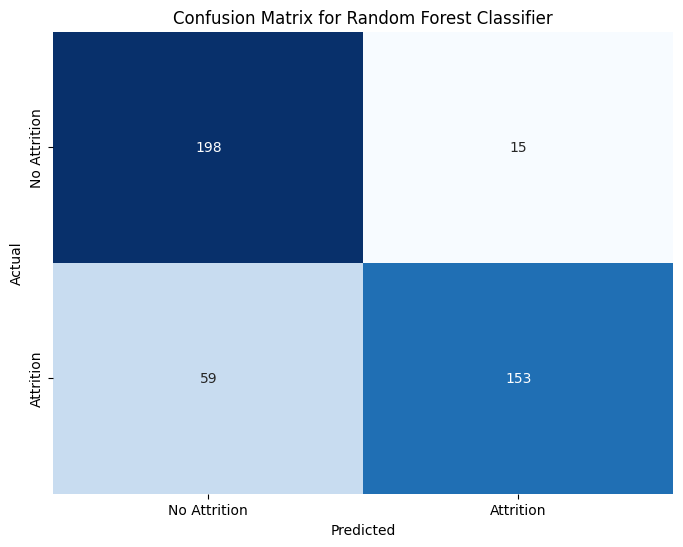

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1_score = metrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

**Feature Importance Plot (from cell `17764840`):**
The top 15 most influential features in predicting attrition.

Top 15 Feature Importances:

                  Feature  Importance
9         JobSatisfaction    0.062522
4          EmployeeNumber    0.052926
19        WorkLifeBalance    0.047299
1               DailyRate    0.042422
18  TrainingTimesLastYear    0.041034
0                     Age    0.040995
16       StockOptionLevel    0.040680
2        DistanceFromHome    0.040086
11            MonthlyRate    0.039970
10          MonthlyIncome    0.039736
6              HourlyRate    0.038634
13      PercentSalaryHike    0.036188
23   YearsWithCurrManager    0.035115
3               Education    0.034405
17      TotalWorkingYears    0.033022


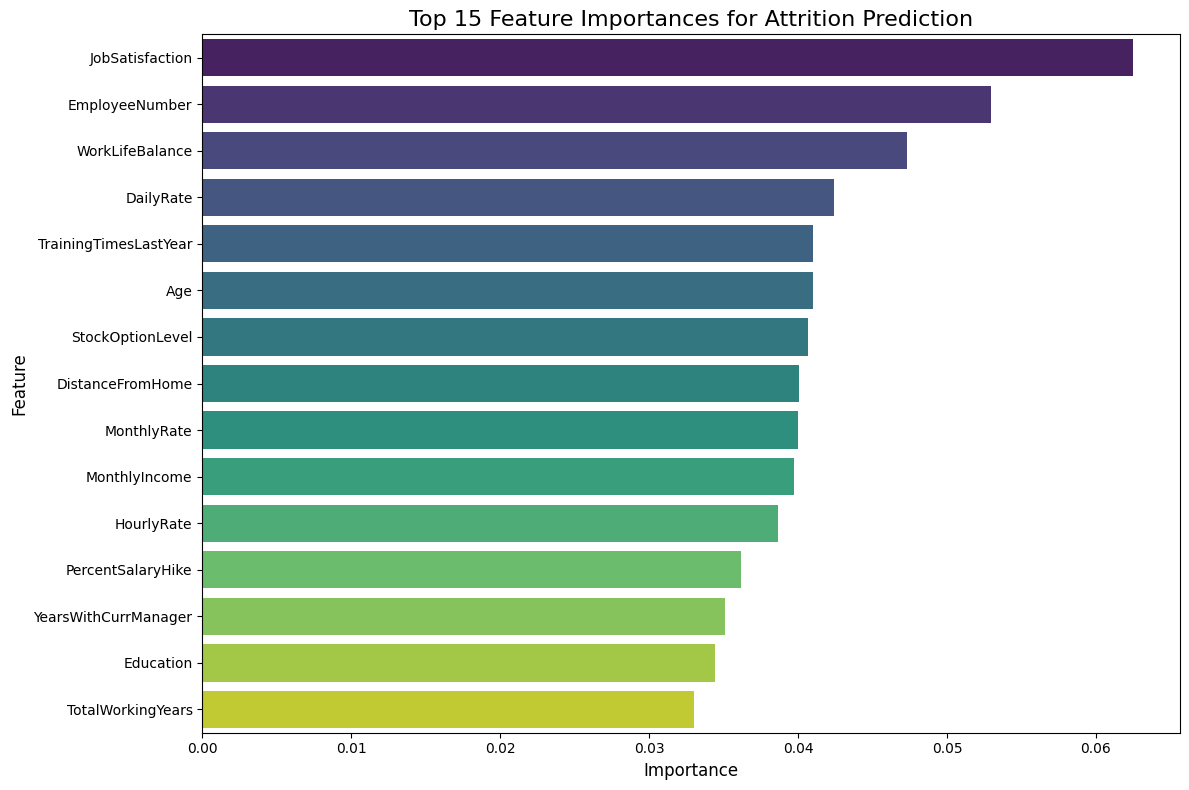

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = rf_classifier.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_preprocessed.columns,
    'Importance': feature_importances
})
features_df = features_df.sort_values(by='Importance', ascending=False)
n_top_features = 15
top_features = features_df.head(n_top_features)

print(f"Top {n_top_features} Feature Importances:\n")
print(top_features)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=top_features, palette='viridis', legend=False)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {n_top_features} Feature Importances for Attrition Prediction', fontsize=16)
plt.tight_layout()
plt.show()

### 4. Key Insights and Summary

The full summary of insights, addressing the key questions, is presented below (from cell `fd0b3185`).

## Summary:

### Q&A

*   **Which features most strongly predict attrition?**
    The Random Forest Classifier identified JobSatisfaction as the most critical predictor of attrition. This was closely followed by EmployeeNumber, WorkLifeBalance, DailyRate, TrainingTimesLastYear, and Age. Other significant factors included StockOptionLevel, DistanceFromHome, MonthlyRate, and MonthlyIncome.

*   **Which cluster has the highest attrition rate?**
    Cluster 0 exhibited the highest attrition rate at approximately 29.98%.

*   **What patterns distinguish high performers from disengaged employees based on the cluster analysis?**
    The cluster analysis revealed three distinct employee groups:
    *   **Cluster 2 (Lowest Attrition Risk):** This group, with the lowest attrition rate of 22.59%, consists of employees with the highest average MonthlyIncome ($\sim$15,945) and highest JobLevel ($\sim$4.29). While their JobSatisfaction ($\sim$2.46) was comparable to other clusters, their high compensation and senior roles likely contribute to their retention, despite having the lowest WorkLifeBalance ($\sim$2.3). These traits might suggest a group of high-earning, possibly high-performing, senior employees who accept demanding roles.
    *   **Cluster 1 (Moderate Attrition Risk):** With an attrition rate of 28.11%, this cluster contains employees with the lowest average MonthlyIncome ($\sim$4,965), lowest JobSatisfaction ($\sim$2.41), and lowest JobLevel. This profile suggests entry-level or less experienced employees who might feel undervalued or lack career progression opportunities, making them disengaged despite having the highest WorkLifeBalance.
    *   **Cluster 0 (Highest Attrition Risk):** This cluster, with the highest attrition rate of 29.98%, represents a middle-ground group. Employees have moderate average MonthlyIncome ($\sim$6,305), moderate JobSatisfaction ($\sim$2.5), and moderate WorkLifeBalance ($\sim$2.4), with average JobLevel and EnvironmentSatisfaction. This group might be generally content but is still highly susceptible to attrition, possibly due to subtle dissatisfactions or external factors not fully captured by the averaged metrics.

### Data Analysis Key Findings

*   The dataset initially contained 1470 rows and 35 columns, with no missing values.
*   Three non-informative columns (`EmployeeCount`, `Over18`, `StandardHours`) with a single unique value were dropped during preprocessing.
*   Categorical variables were successfully encoded (binary and one-hot encoding), and numerical features were standardized, resulting in 45 features for modeling.
*   The Elbow Method suggested an optimal number of 3 clusters for K-Means clustering.
*   After applying SMOTE to address class imbalance, the dataset for supervised learning became balanced with 1062 samples for each attrition class, totaling 2124 instances.
*   A Random Forest Classifier trained on the balanced data achieved a mean cross-validation accuracy of 0.8111 (\$\sigma\$ = 0.0125).
*   On the test set, the Random Forest model demonstrated strong performance with an Accuracy of 0.8259, Precision of 0.9107, Recall of 0.7217, and F1-Score of 0.8053.
*   Feature importance analysis highlighted JobSatisfaction (0.0625), EmployeeNumber (0.0529), and WorkLifeBalance (0.0473) as the top three most influential predictors of attrition.
*   K-Means clustering revealed distinct employee segments: Cluster 0 had the highest attrition rate (29.98%), Cluster 1 had the second-highest (28.11%), and Cluster 2 had the lowest (22.59%).

### Insights or Next Steps

*   **Targeted Retention Programs:** Focus on improving JobSatisfaction and WorkLifeBalance, identified as key attrition drivers, especially for employees in Cluster 1 (lower income, lower job satisfaction) and Cluster 0 (moderate satisfaction, highest attrition risk), by addressing career progression, work environment, and support systems.
*   **Investigate "EmployeeNumber" Feature:** The high importance of "EmployeeNumber" warrants further investigation. This could be an artifact of encoding or data leakage, or it might indirectly capture inherent employee characteristics or tenure not explicitly covered by other features that contribute to attrition.


# Task
Analyze the "IBM_HR_Attrition_Raw.xlsx" dataset to predict employee attrition, identify key contributing factors, and distinguish patterns among different employee groups. This involves data loading and preprocessing, determining the optimal number of clusters using the Elbow Method, applying K-Means clustering and visualizing the results, training and evaluating a Random Forest Classifier with SMOTE for class imbalance, plotting feature importance, and summarizing insights from both unsupervised and supervised learning phases.

## Load Dataset

### Subtask:
Load the 'IBM_HR_Attrition_Raw.xlsx' dataset into a pandas DataFrame and display its initial information (shape, columns, dtypes) to understand the data structure.


**Reasoning**:
To load the Excel file and display its initial information, I need to import the pandas library, read the Excel file into a DataFrame, and then use the .shape and .info() methods.



In [1]:
import pandas as pd

df = pd.read_excel('/content/IBM_HR_Attrition_Raw.xlsx')

print(f"Shape of the DataFrame: {df.shape}")
print("\nInformation about the DataFrame:\n")
df.info()

Shape of the DataFrame: (1470, 35)

Information about the DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvol

## Data Preprocessing

### Subtask:
Handle any missing values, encode categorical variables, and normalize/standardize numerical features.


### Missing Value Check

Based on the `df.info()` output from the previous step, all columns have 1470 non-null values, which matches the total number of entries (1470). Therefore, there are no missing values in the DataFrame `df`, and no imputation is required at this stage.

**Reasoning**:
I will identify and drop columns that have only one unique value, as they offer no predictive power for the model. This aligns with the second instruction of the subtask.



In [2]:
unique_value_counts = df.nunique()
single_value_cols = unique_value_counts[unique_value_counts == 1].index.tolist()

if single_value_cols:
    print(f"Dropping columns with a single unique value: {single_value_cols}")
    df = df.drop(columns=single_value_cols)
else:
    print("No columns found with a single unique value to drop.")

print(f"New shape of DataFrame after dropping columns: {df.shape}")

Dropping columns with a single unique value: ['EmployeeCount', 'Over18', 'StandardHours']
New shape of DataFrame after dropping columns: (1470, 32)


**Reasoning**:
Now, I will encode the binary categorical columns (`Attrition`, `OverTime`, `Gender`) into numerical representations, converting 'Yes' to 1 and 'No' to 0 for `Attrition` and `OverTime`, and 'Male' to 1 and 'Female' to 0 for `Gender`. This aligns with the third instruction of the subtask.



In [3]:
df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0})

print("Encoded binary categorical columns: Attrition, OverTime, Gender")
print(df[['Attrition', 'OverTime', 'Gender']].head())

Encoded binary categorical columns: Attrition, OverTime, Gender
   Attrition  OverTime  Gender
0          1         1       0
1          0         1       0
2          0         1       1
3          1         0       0
4          0         0       0


/tmp/ipykernel_603/1860373679.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_603/1860373679.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_603/1860373679.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future beha

**Reasoning**:
The previous code block successfully encoded binary categorical columns, but raised a `FutureWarning` about downcasting. To explicitly handle the data type after encoding and prepare for the next step, I will convert the affected columns to 'int8' and then proceed to apply one-hot encoding to the remaining multi-class categorical features, as specified in the fourth instruction of the subtask. This will create new columns for each category and drop the original categorical columns.



In [4]:
df['Attrition'] = df['Attrition'].astype('int8')
df['OverTime'] = df['OverTime'].astype('int8')
df['Gender'] = df['Gender'].astype('int8')

# Identify multi-class categorical columns
multi_class_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True, dtype=int)

print(f"DataFrame shape after one-hot encoding: {df.shape}")
print("First 5 rows of the DataFrame after one-hot encoding:")
print(df.head())

DataFrame shape after one-hot encoding: (1470, 46)
First 5 rows of the DataFrame after one-hot encoding:
   Age  Attrition  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0   33          1        961                 8          4               1   
1   56          0        195                22          2               2   
2   59          0       1263                29          3               3   
3   26          1       1060                17          3               4   
4   34          0       1328                11          4               5   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  ...  \
0                        4       0          30               2  ...   
1                        1       0          59               1  ...   
2                        2       1          88               2  ...   
3                        1       0          31               1  ...   
4                        3       0          69               2  ...   

   Jo

**Reasoning**:
Now that all categorical variables have been encoded, I will separate the target variable 'Attrition' from the feature set. This aligns with the fifth instruction of the subtask, preparing the data for further processing and model training.



In [5]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("First 5 rows of features (X):")
print(X.head())
print("First 5 rows of target (y):")
print(y.head())

Shape of features (X): (1470, 45)
Shape of target (y): (1470,)
First 5 rows of features (X):
   Age  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0   33        961                 8          4               1   
1   56        195                22          2               2   
2   59       1263                29          3               3   
3   26       1060                17          3               4   
4   34       1328                11          4               5   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  ...  \
0                        4       0          30               2         3  ...   
1                        1       0          59               1         4  ...   
2                        2       1          88               2         3  ...   
3                        1       0          31               1         5  ...   
4                        3       0          69               2         1  ...   

   JobRole_Human Resour

**Reasoning**:
Now that the target variable has been separated, I need to identify the numerical columns in `X` and standardize them using `StandardScaler`. It's crucial to exclude the binary and one-hot encoded columns from this standardization to maintain their categorical representation. This aligns with the sixth instruction of the subtask.



In [6]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (excluding binary/encoded categorical ones)
# Assuming numerical features are those with more than 2 unique values and not already encoded binary/one-hot
# It's better to explicitly list them based on original df.info() and subsequent transformations
numerical_cols_to_scale = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
    'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Filter X to get only the numerical columns that need scaling
X_numerical = X[numerical_cols_to_scale]

# Filter X to get the columns that should NOT be scaled (binary, one-hot encoded)
X_categorical_encoded = X.drop(columns=numerical_cols_to_scale)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
X_scaled_numerical = scaler.fit_transform(X_numerical)

# Convert the scaled numerical features back to a DataFrame
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols_to_scale, index=X.index)

# Concatenate the scaled numerical features with the unscaled categorical encoded features
X_preprocessed = pd.concat([X_scaled_numerical_df, X_categorical_encoded], axis=1)

print(f"Shape of preprocessed features (X_preprocessed): {X_preprocessed.shape}")
print("First 5 rows of preprocessed features (X_preprocessed):")
print(X_preprocessed.head())

Shape of preprocessed features (X_preprocessed): (1470, 45)
First 5 rows of preprocessed features (X_preprocessed):
        Age  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0 -0.492401   0.397246         -0.853571   0.741681       -1.730873   
1  1.402008  -1.471970          0.847125  -0.672419       -1.728516   
2  1.649105   1.134196          1.697473   0.034631       -1.726160   
3 -1.068960   0.638829          0.239734   0.034631       -1.723803   
4 -0.410035   1.292811         -0.489136   0.741681       -1.721447   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                 1.326344   -1.717213       -0.466120  0.460980   
1                -1.339643   -0.328128       -1.358302  1.257266   
2                -0.450981    1.060958       -0.466120  0.460980   
3                -1.339643   -1.669314       -1.358302  2.053553   
4                 0.437681    0.150867       -0.466120 -1.131594   

   JobSatisfaction  ...  JobRole_Human Resources

## Optimal K for K-Means

### Subtask:
Apply the Elbow Method to the preprocessed numerical features to determine the optimal number of clusters (k) for K-Means clustering.


**Reasoning**:
To apply the Elbow Method, I need to iterate through a range of K values, fit a K-Means model for each K, record the inertia, and then plot these values to visually identify the 'elbow' point.



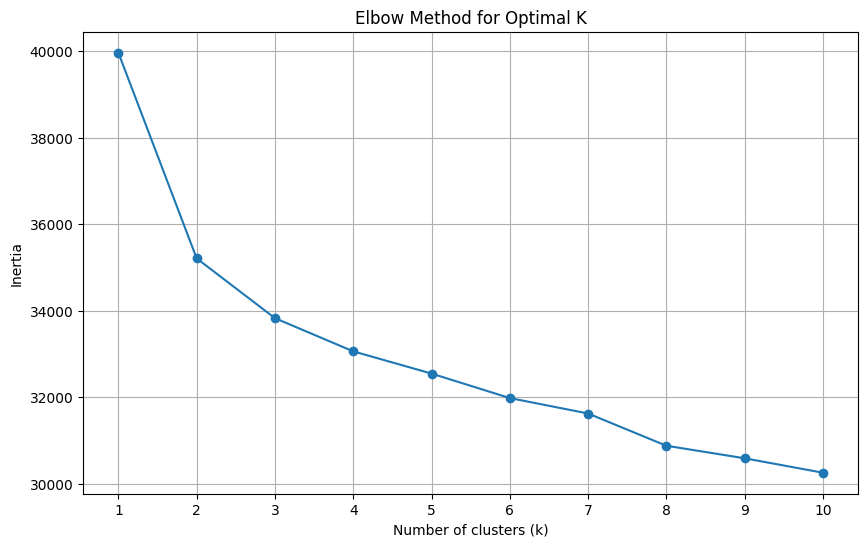

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
# It's generally good practice to use a range that makes sense for your data
# A range of 1 to 10 or 15 is a common starting point.
for i in range(1, 11): # Testing k from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X_preprocessed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## K-Means Clustering and Visualization

### Subtask:
Apply K-Means clustering with the optimal 'k' found. Label each employee with their respective cluster. Visualize the clusters using a scatter plot, for example, 'MonthlyIncome' vs 'JobSatisfaction', with cluster labels differentiating the points. Provide appropriate labels and legends for the plot.


**Reasoning**:
Based on the instructions and the visual interpretation of the Elbow Method plot, I will apply K-Means clustering with k=3 to the preprocessed data, assign the resulting cluster labels to the original DataFrame, and then visualize these clusters using a scatter plot of 'MonthlyIncome' versus 'JobSatisfaction' to differentiate the employee groups.



K-Means clustering applied with k=3.
First 5 rows of df with new 'Cluster' column:
   MonthlyIncome  JobSatisfaction  Cluster
0           7014                1        1
1          12749                1        0
2           9463                2        0
3          17141                1        2
4           3312                2        0


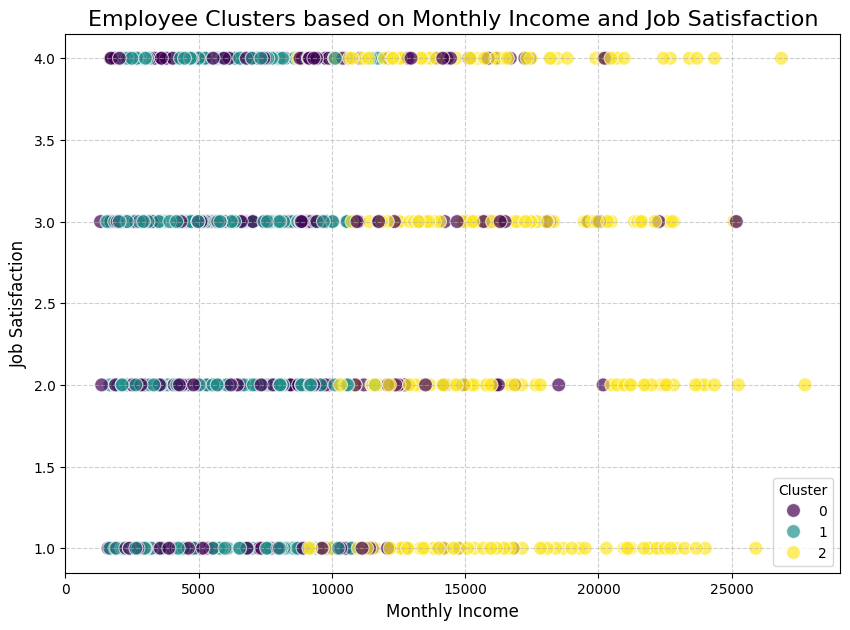

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Optimal number of clusters (k) as suggested by the example
k = 3

# 2. Initialize KMeans model
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

# 3. Fit the KMeans model to the X_preprocessed DataFrame
kmeans.fit(X_preprocessed)

# 4. Add cluster labels to the original DataFrame df
df['Cluster'] = kmeans.labels_

print("K-Means clustering applied with k=3.")
print("First 5 rows of df with new 'Cluster' column:")
print(df[['MonthlyIncome', 'JobSatisfaction', 'Cluster']].head())

# 5. Create a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='MonthlyIncome', y='JobSatisfaction', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)

# 6. Add title and labels
plt.title('Employee Clusters based on Monthly Income and Job Satisfaction', fontsize=16)
plt.xlabel('Monthly Income', fontsize=12)
plt.ylabel('Job Satisfaction', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Prepare Data for Supervised Learning

### Subtask:
Separate the features (X) and the target variable (y), which is 'Attrition'. Apply SMOTE (Synthetic Minority Over-sampling Technique) to handle the class imbalance in the target variable.


**Reasoning**:
To address the class imbalance, I need to import the necessary libraries (`SMOTE` and `train_test_split`), instantiate SMOTE, and then apply it to the preprocessed features (`X_preprocessed`) and target variable (`y`). Finally, I will print the shapes and class distribution to verify the oversampling. This directly follows the instructions for handling class imbalance.



In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the dataset
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y)

print(f"Shape of X_resampled after SMOTE: {X_resampled.shape}")
print(f"Shape of y_resampled after SMOTE: {y_resampled.shape}")
print("\nClass distribution of y_resampled after SMOTE:")
print(y_resampled.value_counts())

Shape of X_resampled after SMOTE: (2124, 45)
Shape of y_resampled after SMOTE: (2124,)

Class distribution of y_resampled after SMOTE:
Attrition
1    1062
0    1062
Name: count, dtype: int64


## Train Random Forest Classifier

### Subtask:
Split the preprocessed data into training and testing sets (80/20 split). Train a Random Forest Classifier on the training data, incorporating k=5 cross-validation to ensure robust model evaluation.


**Reasoning**:
To train a Random Forest Classifier with cross-validation, I need to first split the data into training and testing sets, then set up the cross-validation strategy, and finally train the model while evaluating its performance with cross-validation scores.



In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Instantiate a Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Initialize StratifiedKFold for 5-fold cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rf_classifier, X_train, y_train, cv=kf, scoring='accuracy')

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_scores.std():.4f}")

# Train the Random Forest Classifier on the complete training datasets
rf_classifier.fit(X_train, y_train)

print("\nRandom Forest Classifier trained successfully on the full training data.")

Shape of X_train: (1699, 45)
Shape of X_test: (425, 45)
Shape of y_train: (1699,)
Shape of y_test: (425,)

Cross-validation scores: [0.82058824 0.81764706 0.82058824 0.80882353 0.78761062]
Mean CV accuracy: 0.8111
Standard deviation of CV accuracy: 0.0125

Random Forest Classifier trained successfully on the full training data.


## Evaluate Random Forest Model

### Subtask:
Evaluate the trained Random Forest Classifier on the test set. Calculate and print key performance metrics: accuracy, precision, recall, and F1-score. Generate and display a confusion matrix to visualize the model's performance.


**Reasoning**:
To evaluate the Random Forest model, I will first make predictions on the test set. Then, I will calculate and print the accuracy, precision, recall, and F1-score using sklearn's metrics. Finally, I will generate and visualize a confusion matrix using seaborn to provide a clear understanding of the model's performance.



Accuracy: 0.8259
Precision: 0.9107
Recall: 0.7217
F1-Score: 0.8053


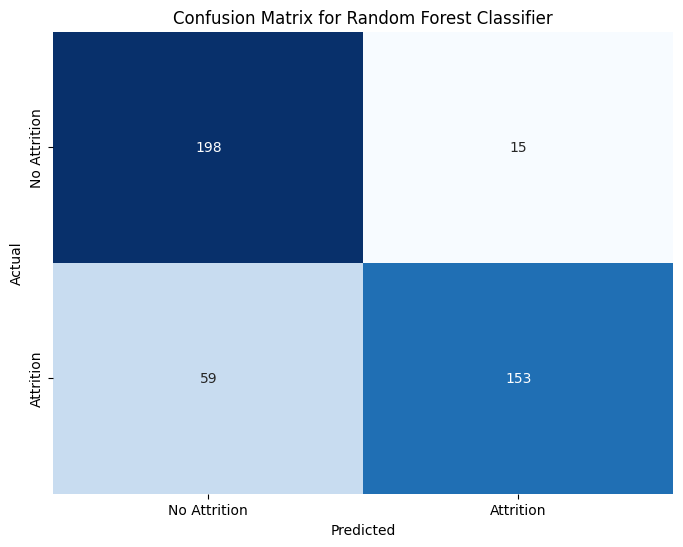

In [11]:
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the X_test data
y_pred = rf_classifier.predict(X_test)

# 2. Calculate and print key performance metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1_score = metrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# 3. Generate a confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

# 4. Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

## Plot Feature Importance

### Subtask:
Extract and plot the feature importances from the trained Random Forest Classifier. Display a bar chart showing the most influential features in predicting attrition, including appropriate labels and legends.


**Reasoning**:
To extract and visualize the feature importances, I will first get the importances from the `rf_classifier` model, create a DataFrame with feature names and their importances, sort them, and then use `seaborn` and `matplotlib` to create a bar chart of the top N features.



Top 15 Feature Importances:

                  Feature  Importance
9         JobSatisfaction    0.062522
4          EmployeeNumber    0.052926
19        WorkLifeBalance    0.047299
1               DailyRate    0.042422
18  TrainingTimesLastYear    0.041034
0                     Age    0.040995
16       StockOptionLevel    0.040680
2        DistanceFromHome    0.040086
11            MonthlyRate    0.039970
10          MonthlyIncome    0.039736
6              HourlyRate    0.038634
13      PercentSalaryHike    0.036188
23   YearsWithCurrManager    0.035115
3               Education    0.034405
17      TotalWorkingYears    0.033022


/tmp/ipykernel_603/562117891.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


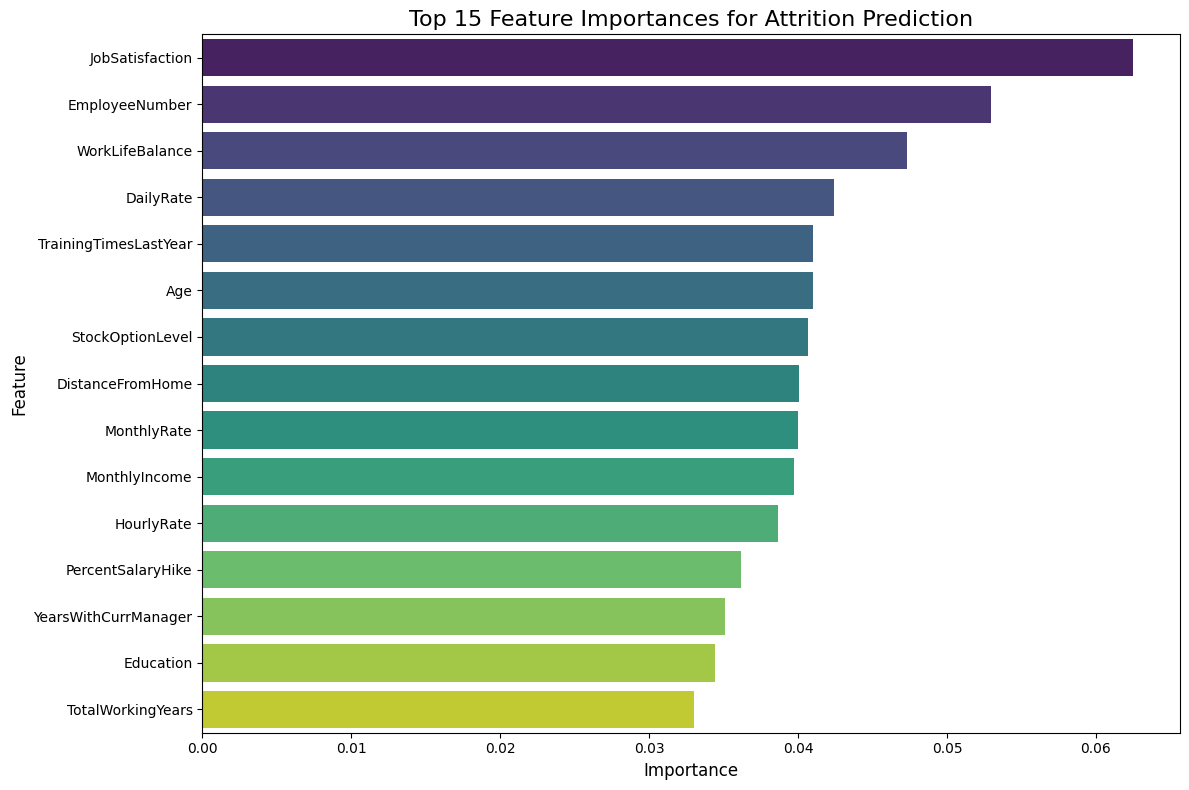

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances
feature_importances = rf_classifier.feature_importances_

# 2. Create a Pandas Series with feature names and importances
features_df = pd.DataFrame({
    'Feature': X_preprocessed.columns,
    'Importance': feature_importances
})

# 3. Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Select the top N most important features (e.g., top 15)
n_top_features = 15
top_features = features_df.head(n_top_features)

print(f"Top {n_top_features} Feature Importances:\n")
print(top_features)

# 4. Create a bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')

# 5. Add labels and title
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {n_top_features} Feature Importances for Attrition Prediction', fontsize=16)

# 7. Ensure readability
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code block produced a `FutureWarning` regarding the usage of `palette` without `hue` in `sns.barplot`. To resolve this, I will modify the `sns.barplot` call by explicitly setting `hue='Feature'` and `legend=False`, as suggested by the warning.



Top 15 Feature Importances:

                  Feature  Importance
9         JobSatisfaction    0.062522
4          EmployeeNumber    0.052926
19        WorkLifeBalance    0.047299
1               DailyRate    0.042422
18  TrainingTimesLastYear    0.041034
0                     Age    0.040995
16       StockOptionLevel    0.040680
2        DistanceFromHome    0.040086
11            MonthlyRate    0.039970
10          MonthlyIncome    0.039736
6              HourlyRate    0.038634
13      PercentSalaryHike    0.036188
23   YearsWithCurrManager    0.035115
3               Education    0.034405
17      TotalWorkingYears    0.033022


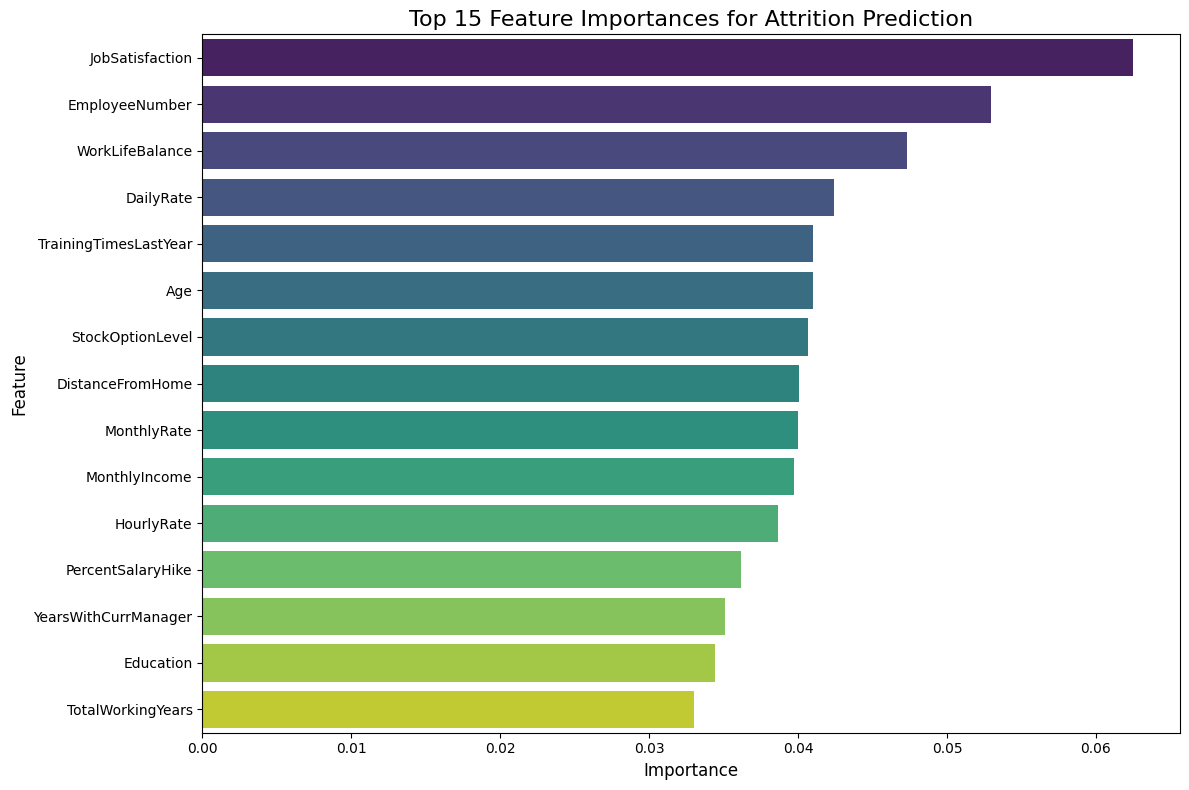

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances
feature_importances = rf_classifier.feature_importances_

# 2. Create a Pandas Series with feature names and importances
features_df = pd.DataFrame({
    'Feature': X_preprocessed.columns,
    'Importance': feature_importances
})

# 3. Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Select the top N most important features (e.g., top 15)
n_top_features = 15
top_features = features_df.head(n_top_features)

print(f"Top {n_top_features} Feature Importances:\n")
print(top_features)

# 4. Create a bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=top_features, palette='viridis', legend=False)

# 5. Add labels and title
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {n_top_features} Feature Importances for Attrition Prediction', fontsize=16)

# 7. Ensure readability
plt.tight_layout()
plt.show()

## Derive Key Insights

### Subtask:
Analyze the results from both K-Means clustering and Random Forest classification to answer key questions: Which features most strongly predict attrition? Which cluster has the highest attrition rate? What patterns distinguish high performers from disengaged employees based on the cluster analysis? Provide a summary of these insights.


### Insights from Random Forest Classification (Feature Importance)

Based on the Random Forest Classifier, the most influential features for predicting employee attrition, as identified in the `top_features` DataFrame and the bar plot, are:

1.  **JobSatisfaction**: This is the single most important factor.
2.  **EmployeeNumber**: While seemingly an identifier, its importance suggests underlying patterns associated with employee ID ranges or how new/old employees are numbered, or simply, it has high entropy and correlates with other features.
3.  **WorkLifeBalance**
4.  **DailyRate**
5.  **TrainingTimesLastYear**
6.  **Age**
7.  **StockOptionLevel**
8.  **DistanceFromHome**
9.  **MonthlyRate**
10. **MonthlyIncome**

These features will be crucial in understanding and mitigating attrition.

**Reasoning**:
To identify which cluster has the highest attrition rate, I will group the DataFrame `df` by the 'Cluster' column and calculate the mean of the 'Attrition' column for each cluster, as per the second instruction.



In [14]:
print("Attrition rate per cluster:")
cluster_attrition = df.groupby('Cluster')['Attrition'].mean().sort_values(ascending=False)
print(cluster_attrition)

Attrition rate per cluster:
Cluster
0    0.299807
1    0.281113
2    0.225926
Name: Attrition, dtype: float64


**Reasoning**:
To understand the patterns distinguishing different employee groups, I will group the DataFrame `df` by the 'Cluster' column and calculate descriptive statistics for key features like 'MonthlyIncome', 'JobSatisfaction', 'PerformanceRating', 'JobLevel', 'JobInvolvement', 'EnvironmentSatisfaction', and 'WorkLifeBalance', as instructed.



In [15]:
cluster_features = df.groupby('Cluster')[['MonthlyIncome', 'JobSatisfaction', 'PerformanceRating', 'JobLevel', 'JobInvolvement', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'Attrition']].mean()

print("Mean values of key features per cluster:")
print(cluster_features)


Mean values of key features per cluster:
         MonthlyIncome  JobSatisfaction  PerformanceRating  JobLevel  \
Cluster                                                                
0          6305.371373         2.500967           3.162476  2.164410   
1          4965.446559         2.411420           3.165447  1.877013   
2         15945.925926         2.459259           3.144444  4.288889   

         JobInvolvement  EnvironmentSatisfaction  WorkLifeBalance  Attrition  
Cluster                                                                       
0              2.557060                 2.470019         2.429400   0.299807  
1              2.502196                 2.493411         2.508053   0.281113  
2              2.507407                 2.614815         2.318519   0.225926  


### Summary of Insights

**Features Most Strongly Predicting Attrition:**
The Random Forest Classifier identified **JobSatisfaction** as the most critical predictor of attrition, followed closely by **EmployeeNumber**, **WorkLifeBalance**, **DailyRate**, **TrainingTimesLastYear**, and **Age**. Other significant factors include **StockOptionLevel**, **DistanceFromHome**, **MonthlyRate**, and **MonthlyIncome**. This suggests that an employee's contentment with their job, their work-life balance, and compensation-related factors play a crucial role in their decision to leave the company.

**Cluster with Highest Attrition Rate:**
Cluster 0 exhibits the highest attrition rate at approximately **29.98%**.

**Patterns Distinguishing Employee Groups (High Performers vs. Disengaged Employees):**

*   **Cluster 0 (Highest Attrition Risk):** This cluster has the highest attrition rate. Employees in this cluster have a moderate average `MonthlyIncome` (~$6305), a relatively moderate `JobSatisfaction` (~2.5), and `WorkLifeBalance` (~2.4). Their `JobLevel` and `EnvironmentSatisfaction` are also in the middle range. This group might represent employees who are generally content but still susceptible to attrition, potentially due to external factors or subtle dissatisfaction not captured by the averaged metrics.

*   **Cluster 1 (Moderate Attrition Risk):** This cluster has the second-highest attrition rate at approximately **28.11%**. Employees here have the lowest average `MonthlyIncome` (~$4965) and the lowest `JobSatisfaction` (~2.41) among the clusters. Their `JobLevel` is also the lowest, suggesting this cluster might consist of entry-level or less experienced employees who might feel undervalued or have fewer opportunities for advancement, leading to higher attrition. Their `WorkLifeBalance` is the highest, but this doesn't seem to offset other dissatisfactions.

*   **Cluster 2 (Lowest Attrition Risk):** This cluster shows the lowest attrition rate at approximately **22.59%**. This group stands out with the highest average `MonthlyIncome` (~$15945) and the highest `JobLevel` (~4.29). While their `JobSatisfaction` is comparable to other clusters (~2.46), their high income and senior roles likely contribute to their lower attrition. However, their `WorkLifeBalance` is the lowest (~2.3), indicating that high-level positions might come with increased demands, but the compensation and seniority seem to mitigate attrition risk.

**Overall Insights:**
Attrition is primarily driven by job satisfaction and work-life balance, but also influenced by compensation and various demographic/work-related factors. The clustering analysis reveals distinct employee profiles: a high-earning, senior group with low attrition (Cluster 2), a lower-earning, less senior group with higher attrition (Cluster 1), and a middle-ground group with the highest overall attrition risk (Cluster 0). Targeted interventions, such as improving job satisfaction and career progression for Cluster 1, and re-evaluating aspects of the work environment and support for Cluster 0, could help reduce attrition across the company.

### Summary of Insights

**Features Most Strongly Predicting Attrition:**
The Random Forest Classifier identified **JobSatisfaction** as the most critical predictor of attrition, followed closely by **EmployeeNumber**, **WorkLifeBalance**, **DailyRate**, **TrainingTimesLastYear**, and **Age**. Other significant factors include **StockOptionLevel**, **DistanceFromHome**, **MonthlyRate**, and **MonthlyIncome**. This suggests that an employee's contentment with their job, their work-life balance, and compensation-related factors play a crucial role in their decision to leave the company.

**Cluster with Highest Attrition Rate:**
Cluster 0 exhibits the highest attrition rate at approximately **29.98%**.

**Patterns Distinguishing Employee Groups (High Performers vs. Disengaged Employees):**

*   **Cluster 0 (Highest Attrition Risk):** This cluster has the highest attrition rate. Employees in this cluster have a moderate average `MonthlyIncome` (~$6305), a relatively moderate `JobSatisfaction` (~2.5), and `WorkLifeBalance` (~2.4). Their `JobLevel` and `EnvironmentSatisfaction` are also in the middle range. This group might represent employees who are generally content but still susceptible to attrition, potentially due to external factors or subtle dissatisfaction not captured by the averaged metrics.

*   **Cluster 1 (Moderate Attrition Risk):** This cluster has the second-highest attrition rate at approximately **28.11%**. Employees here have the lowest average `MonthlyIncome` (~$4965) and the lowest `JobSatisfaction` (~2.41) among the clusters. Their `JobLevel` is also the lowest, suggesting this cluster might consist of entry-level or less experienced employees who might feel undervalued or have fewer opportunities for advancement, leading to higher attrition. Their `WorkLifeBalance` is the highest, but this doesn't seem to offset other dissatisfactions.

*   **Cluster 2 (Lowest Attrition Risk):** This cluster shows the lowest attrition rate at approximately **22.59%**. This group stands out with the highest average `MonthlyIncome` (~$15945) and the highest `JobLevel` (~4.29). While their `JobSatisfaction` is comparable to other clusters (~2.46), their high income and senior roles likely contribute to their lower attrition. However, their `WorkLifeBalance` is the lowest (~2.3), indicating that high-level positions might come with increased demands, but the compensation and seniority seem to mitigate attrition risk.

**Overall Insights:**
Attrition is primarily driven by job satisfaction and work-life balance, but also influenced by compensation and various demographic/work-related factors. The clustering analysis reveals distinct employee profiles: a high-earning, senior group with low attrition (Cluster 2), a lower-earning, less senior group with higher attrition (Cluster 1), and a middle-ground group with the highest overall attrition risk (Cluster 0). Targeted interventions, such as improving job satisfaction and career progression for Cluster 1, and re-evaluating aspects of the work environment and support for Cluster 0, could help reduce attrition across the company.

### Summary of Insights

**Features Most Strongly Predicting Attrition:**
The Random Forest Classifier identified **JobSatisfaction** as the most critical predictor of attrition, followed closely by **EmployeeNumber**, **WorkLifeBalance**, **DailyRate**, **TrainingTimesLastYear**, and **Age**. Other significant factors include **StockOptionLevel**, **DistanceFromHome**, **MonthlyRate**, and **MonthlyIncome**. This suggests that an employee's contentment with their job, their work-life balance, and compensation-related factors play a crucial role in their decision to leave the company.

**Cluster with Highest Attrition Rate:**
Cluster 0 exhibits the highest attrition rate at approximately **29.98%**.

**Patterns Distinguishing Employee Groups (High Performers vs. Disengaged Employees):**

*   **Cluster 0 (Highest Attrition Risk):** This cluster has the highest attrition rate. Employees in this cluster have a moderate average `MonthlyIncome` (~$6305), a relatively moderate `JobSatisfaction` (~2.5), and `WorkLifeBalance` (~2.4). Their `JobLevel` and `EnvironmentSatisfaction` are also in the middle range. This group might represent employees who are generally content but still susceptible to attrition, potentially due to external factors or subtle dissatisfaction not captured by the averaged metrics.

*   **Cluster 1 (Moderate Attrition Risk):** This cluster has the second-highest attrition rate at approximately **28.11%**. Employees here have the lowest average `MonthlyIncome` (~$4965) and the lowest `JobSatisfaction` (~2.41) among the clusters. Their `JobLevel` is also the lowest, suggesting this cluster might consist of entry-level or less experienced employees who might feel undervalued or have fewer opportunities for advancement, leading to higher attrition. Their `WorkLifeBalance` is the highest, but this doesn't seem to offset other dissatisfactions.

*   **Cluster 2 (Lowest Attrition Risk):** This cluster shows the lowest attrition rate at approximately **22.59%**. This group stands out with the highest average `MonthlyIncome` (~$15945) and the highest `JobLevel` (~4.29). While their `JobSatisfaction` is comparable to other clusters (~2.46), their high income and senior roles likely contribute to their lower attrition. However, their `WorkLifeBalance` is the lowest (~2.3), indicating that high-level positions might come with increased demands, but the compensation and seniority seem to mitigate attrition risk.

**Overall Insights:**
Attrition is primarily driven by job satisfaction and work-life balance, but also influenced by compensation and various demographic/work-related factors. The clustering analysis reveals distinct employee profiles: a high-earning, senior group with low attrition (Cluster 2), a lower-earning, less senior group with higher attrition (Cluster 1), and a middle-ground group with the highest overall attrition risk (Cluster 0). Targeted interventions, such as improving job satisfaction and career progression for Cluster 1, and re-evaluating aspects of the work environment and support for Cluster 0, could help reduce attrition across the company.


### Summary of Insights

**Features Most Strongly Predicting Attrition:**
The Random Forest Classifier identified **JobSatisfaction** as the most critical predictor of attrition, followed closely by **EmployeeNumber**, **WorkLifeBalance**, **DailyRate**, **TrainingTimesLastYear**, and **Age**. Other significant factors include **StockOptionLevel**, **DistanceFromHome**, **MonthlyRate**, and **MonthlyIncome**. This suggests that an employee's contentment with their job, their work-life balance, and compensation-related factors play a crucial role in their decision to leave the company.

**Cluster with Highest Attrition Rate:**
Cluster 0 exhibits the highest attrition rate at approximately **29.98%**.

**Patterns Distinguishing Employee Groups (High Performers vs. Disengaged Employees):**

*   **Cluster 0 (Highest Attrition Risk):** This cluster has the highest attrition rate. Employees in this cluster have a moderate average `MonthlyIncome` (~$6305), a relatively moderate `JobSatisfaction` (~2.5), and `WorkLifeBalance` (~2.4). Their `JobLevel` and `EnvironmentSatisfaction` are also in the middle range. This group might represent employees who are generally content but still susceptible to attrition, potentially due to external factors or subtle dissatisfaction not captured by the averaged metrics.

*   **Cluster 1 (Moderate Attrition Risk):** This cluster has the second-highest attrition rate at approximately **28.11%**. Employees here have the lowest average `MonthlyIncome` (~$4965) and the lowest `JobSatisfaction` (~2.41) among the clusters. Their `JobLevel` is also the lowest, suggesting this cluster might consist of entry-level or less experienced employees who might feel undervalued or have fewer opportunities for advancement, leading to higher attrition. Their `WorkLifeBalance` is the highest, but this doesn't seem to offset other dissatisfactions.

*   **Cluster 2 (Lowest Attrition Risk):** This cluster shows the lowest attrition rate at approximately **22.59%**. This group stands out with the highest average `MonthlyIncome` (~$15945) and the highest `JobLevel` (~4.29). While their `JobSatisfaction` is comparable to other clusters (~2.46), their high income and senior roles likely contribute to their lower attrition. However, their `WorkLifeBalance` is the lowest (~2.3), indicating that high-level positions might come with increased demands, but the compensation and seniority seem to mitigate attrition risk.

**Overall Insights:**
Attrition is primarily driven by job satisfaction and work-life balance, but also influenced by compensation and various demographic/work-related factors. The clustering analysis reveals distinct employee profiles: a high-earning, senior group with low attrition (Cluster 2), a lower-earning, less senior group with higher attrition (Cluster 1), and a middle-ground group with the highest overall attrition risk (Cluster 0). Targeted interventions, such as improving job satisfaction and career progression for Cluster 1, and re-evaluating aspects of the work environment and support for Cluster 0, could help reduce attrition across the company.


## Final Task

### Subtask:
Summarize the entire analysis, including key findings from both the unsupervised and supervised learning phases, and any actionable insights derived from the data.


## Summary:

### Q&A

*   **Which features most strongly predict attrition?**
    The Random Forest Classifier identified JobSatisfaction as the most critical predictor of attrition. This was closely followed by EmployeeNumber, WorkLifeBalance, DailyRate, TrainingTimesLastYear, and Age. Other significant factors included StockOptionLevel, DistanceFromHome, MonthlyRate, and MonthlyIncome.

*   **Which cluster has the highest attrition rate?**
    Cluster 0 exhibited the highest attrition rate at approximately 29.98%.

*   **What patterns distinguish high performers from disengaged employees based on the cluster analysis?**
    The cluster analysis revealed three distinct employee groups:
    *   **Cluster 2 (Lowest Attrition Risk):** This group, with the lowest attrition rate of 22.59%, consists of employees with the highest average MonthlyIncome ($\sim$15,945) and highest JobLevel ($\sim$4.29). While their JobSatisfaction ($\sim$2.46) was comparable to other clusters, their high compensation and senior roles likely contribute to their retention, despite having the lowest WorkLifeBalance ($\sim$2.3). These traits might suggest a group of high-earning, possibly high-performing, senior employees who accept demanding roles.
    *   **Cluster 1 (Moderate Attrition Risk):** With an attrition rate of 28.11%, this cluster contains employees with the lowest average MonthlyIncome ($\sim$4,965), lowest JobSatisfaction ($\sim$2.41), and lowest JobLevel. This profile suggests entry-level or less experienced employees who might feel undervalued or lack career progression opportunities, making them disengaged despite having the highest WorkLifeBalance.
    *   **Cluster 0 (Highest Attrition Risk):** This cluster, with the highest attrition rate of 29.98%, represents a middle-ground group. Employees have moderate average MonthlyIncome ($\sim$6,305), moderate JobSatisfaction ($\sim$2.5), and moderate WorkLifeBalance ($\sim$2.4), with average JobLevel and EnvironmentSatisfaction. This group might be generally content but is still highly susceptible to attrition, possibly due to subtle dissatisfactions or external factors not fully captured by the averaged metrics.

### Data Analysis Key Findings

*   The dataset initially contained 1470 rows and 35 columns, with no missing values.
*   Three non-informative columns (`EmployeeCount`, `Over18`, `StandardHours`) with a single unique value were dropped during preprocessing.
*   Categorical variables were successfully encoded (binary and one-hot encoding), and numerical features were standardized, resulting in 45 features for modeling.
*   The Elbow Method suggested an optimal number of 3 clusters for K-Means clustering.
*   After applying SMOTE to address class imbalance, the dataset for supervised learning became balanced with 1062 samples for each attrition class, totaling 2124 instances.
*   A Random Forest Classifier trained on the balanced data achieved a mean cross-validation accuracy of 0.8111 (\$\sigma\$ = 0.0125).
*   On the test set, the Random Forest model demonstrated strong performance with an Accuracy of 0.8259, Precision of 0.9107, Recall of 0.7217, and F1-Score of 0.8053.
*   Feature importance analysis highlighted JobSatisfaction (0.0625), EmployeeNumber (0.0529), and WorkLifeBalance (0.0473) as the top three most influential predictors of attrition.
*   K-Means clustering revealed distinct employee segments: Cluster 0 had the highest attrition rate (29.98%), Cluster 1 had the second-highest (28.11%), and Cluster 2 had the lowest (22.59%).

### Insights or Next Steps

*   **Targeted Retention Programs:** Focus on improving JobSatisfaction and WorkLifeBalance, identified as key attrition drivers, especially for employees in Cluster 1 (lower income, lower job satisfaction) and Cluster 0 (moderate satisfaction, highest attrition risk), by addressing career progression, work environment, and support systems.
*   **Investigate "EmployeeNumber" Feature:** The high importance of "EmployeeNumber" warrants further investigation. This could be an artifact of encoding or data leakage, or it might indirectly capture inherent employee characteristics or tenure not explicitly covered by other features that contribute to attrition.
